# Import libraries

In [12]:
import os
import re
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Retrieve MetaData Information - MLLimbEEG

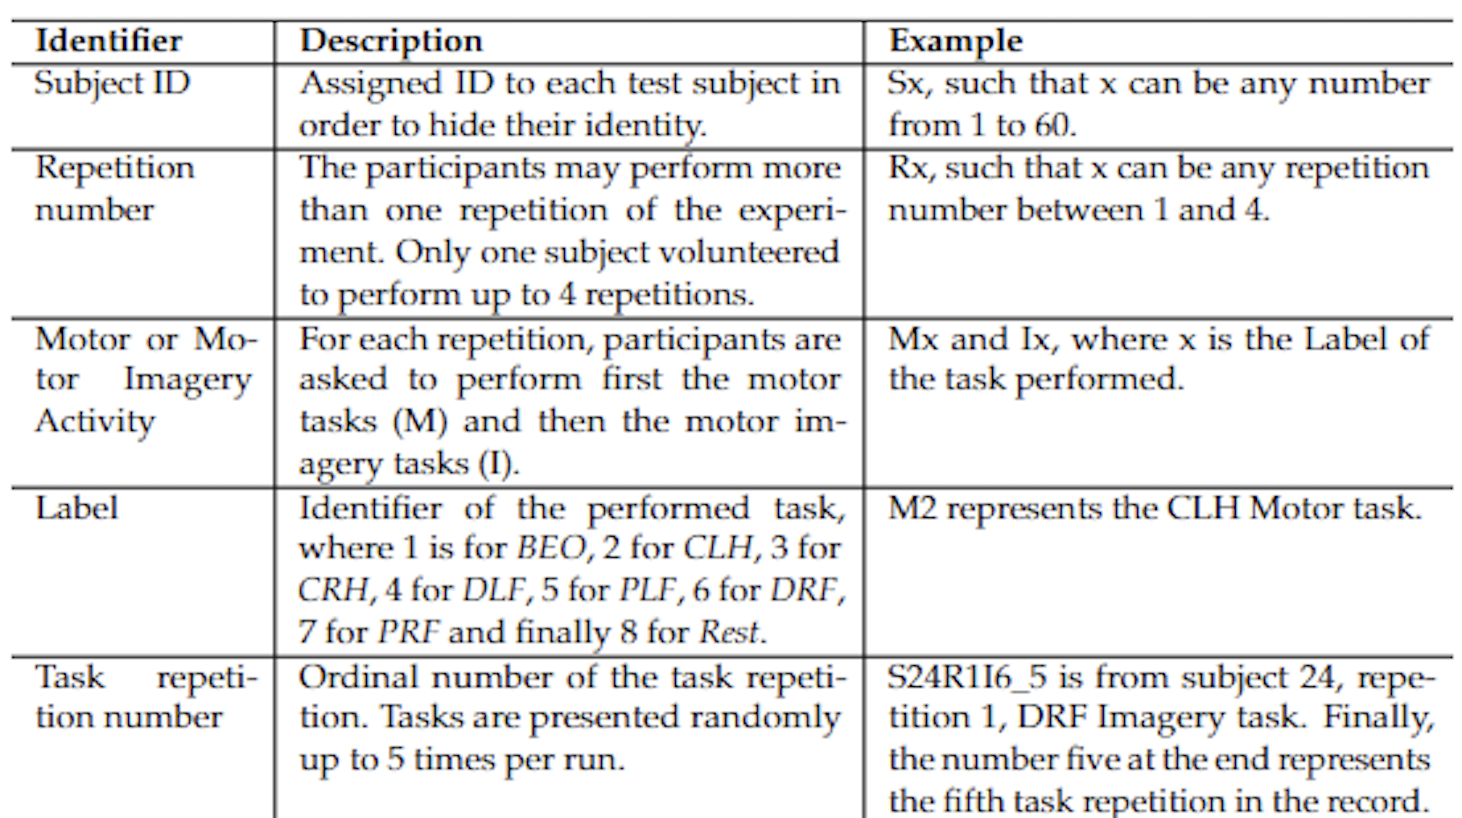

In [2]:
try:
    assert(len([i for i in os.listdir("./data/") if i.startswith("S")]) == 60)
    file_dir = [i for i in os.listdir("./data/") if i.startswith("S")]
    print("All subjects directories are loaded!!")
except:
    print("Error!! Not all subjects directories are loaded")

All subjects directories are loaded!!


In [7]:
def metadata_info(file_folder: str, focusGroup = "M", baselocation = "./data/"):
    """
        Function: This function contains the meta data information about the files
        args:
            file_dir: list of file folders 
    """
    file_folder = os.path.join(baselocation, file_folder)  
    file_folder_dir_lst = os.listdir(file_folder)

    # Retrieve files that contains Motor related EEG signals
    focused_file_lst = [file for file in file_folder_dir_lst if "M" in file]
    focused_file_lst = [file for file in focused_file_lst if "M8" not in file]

    # Extract the required identifiers Subject ID, 
    #                                  Repetition Number, 
    #                                  Motor or Motor Imagery Activity, 
    #                                  label 
    #                                  and Task Repetition Number

    def re_match(filename:str):
        """ Matches the filename into the above mentioned respective groups"""
        match = re.match(r'(S\d+)(R\d+)(M\d+)_([0-9]+)\.csv', filename)

        s_part = match.group(1) # Subject ID component
        r_part = match.group(2) # Repetition ID component
        m_part = match.group(3) # Motor Tasks
        number = int(match.group(4)) # Repetition

        return (filename, s_part, r_part, m_part, number)

    # Create a Pandas dataframe that holds the metadata information and sort based on motor label and Task Repetition No
    meta_info =[re_match(file) for file in focused_file_lst]
    meta_info = pd.DataFrame(meta_info, columns = ["FileName", "SubjectID", "RepetitionNo", "Motor_label", "Task_RepetitionNo"]) 
    meta_info = meta_info.sort_values(by=["Motor_label", "Task_RepetitionNo"], ascending=True).reset_index(drop= True) 

    return meta_info

consolidated_metadata_info = [metadata_info(file_folder=file_str) for file_str in file_dir]
consolidated_metadata_info = pd.concat(consolidated_metadata_info).reset_index(drop = True)

# Split the Dataset into Train and Test Files

In [21]:
subject_id = consolidated_metadata_info["SubjectID"].unique()
train_subject_id, test_subject_id = train_test_split(subject_id, train_size=0.8, random_state=12)
print(f"length of train subject ids: {len(train_subject_id)}")
print(f"length of test subject ids: {len(test_subject_id)}")


# filter the metadata information based on train and test subject ids
train_metadata_information= consolidated_metadata_info[consolidated_metadata_info["SubjectID"].isin(train_subject_id)].reset_index(drop = True)
test_metadata_information= consolidated_metadata_info[consolidated_metadata_info["SubjectID"].isin(test_subject_id)].reset_index(drop = True)

length of train subject ids: 48
length of test subject ids: 12


# Exploratory Analysis

#### Study 1: Pre Normalization of the EEG Signals

In [69]:
def plot_eeg_signal(SubjectID: str, filename: str, label:str):
    eda_df = pd.read_csv(f"./data/{SubjectID}/{filename}.csv")
    eda_df= eda_df.iloc[:, 1:]
    plt.figure(figsize=(15, 5))
    for i in range(0, 16):
        plt.plot(eda_df.iloc[:, i], label = f"Electrode {i}")
        plt.title(f"EEG Signal for Subject {SubjectID}, Repetition R1, Motor ({label}) - 125Hz Sampling Rate")
        plt.xlabel("Sample Points")
        plt.ylabel("Amplitude")
        plt.legend()

    plt.show()

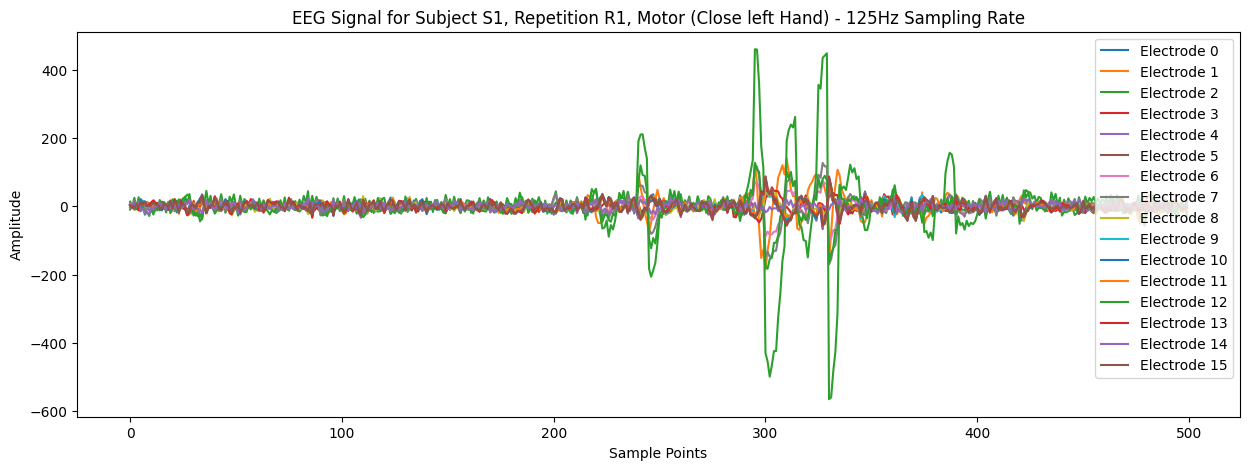

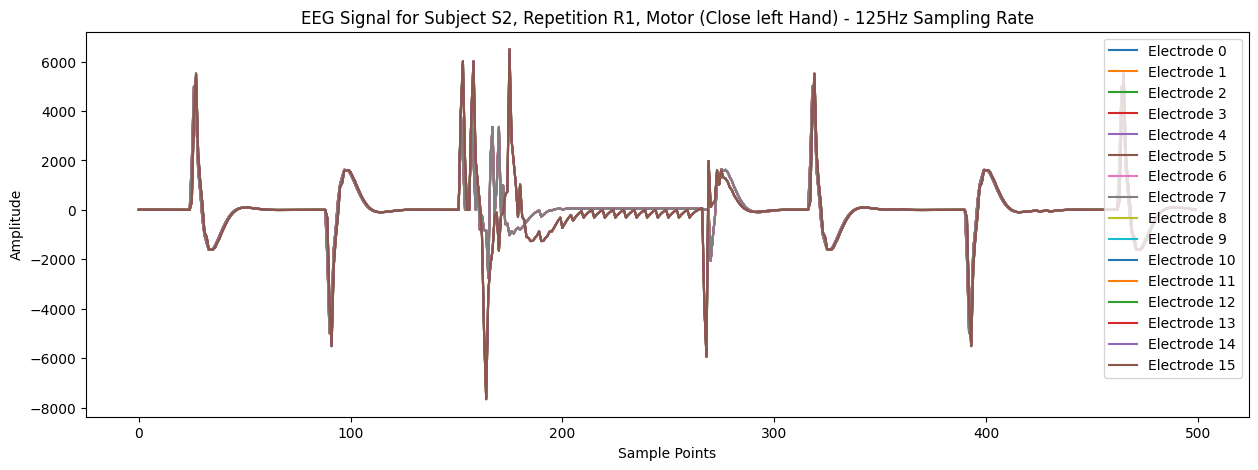

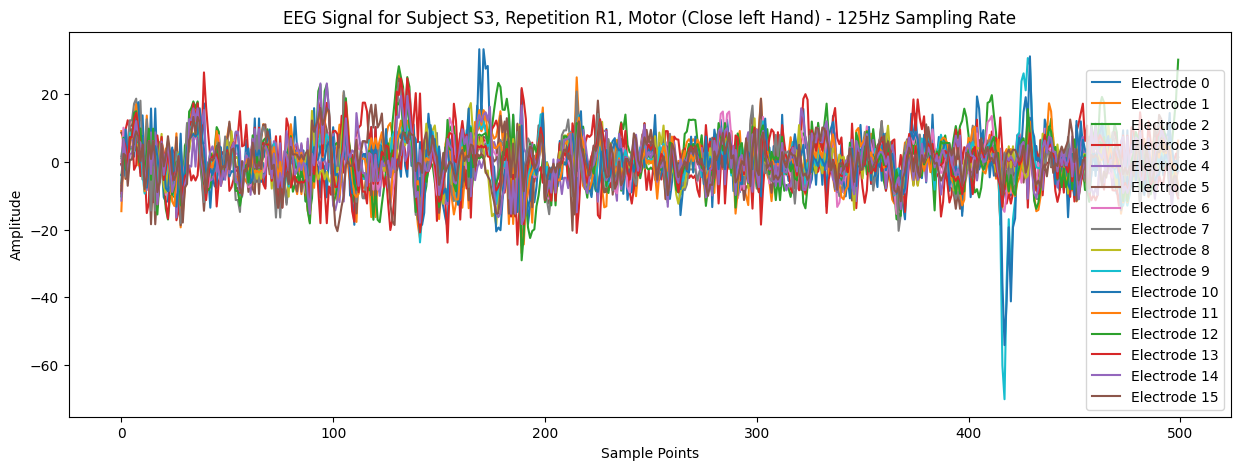

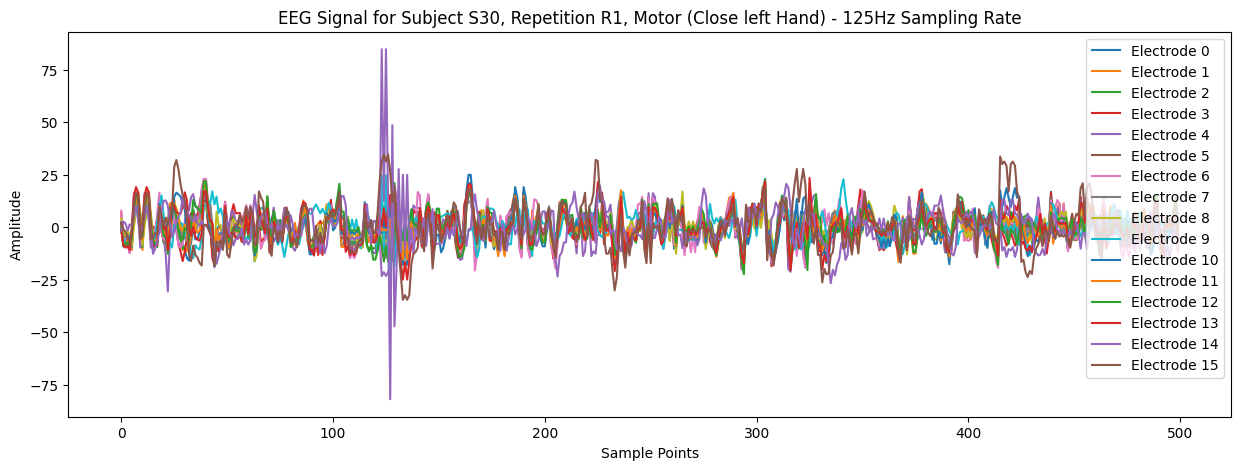

In [70]:
plot_eeg_signal(SubjectID="S1", filename = "S1R1M2_1", label= "Close left Hand")
plot_eeg_signal(SubjectID="S2", filename = "S2R1M2_1", label= "Close left Hand")
plot_eeg_signal(SubjectID="S3", filename = "S3R1M2_1", label= "Close left Hand")
plot_eeg_signal(SubjectID="S30", filename = "S30R1M2_1", label= "Close left Hand")

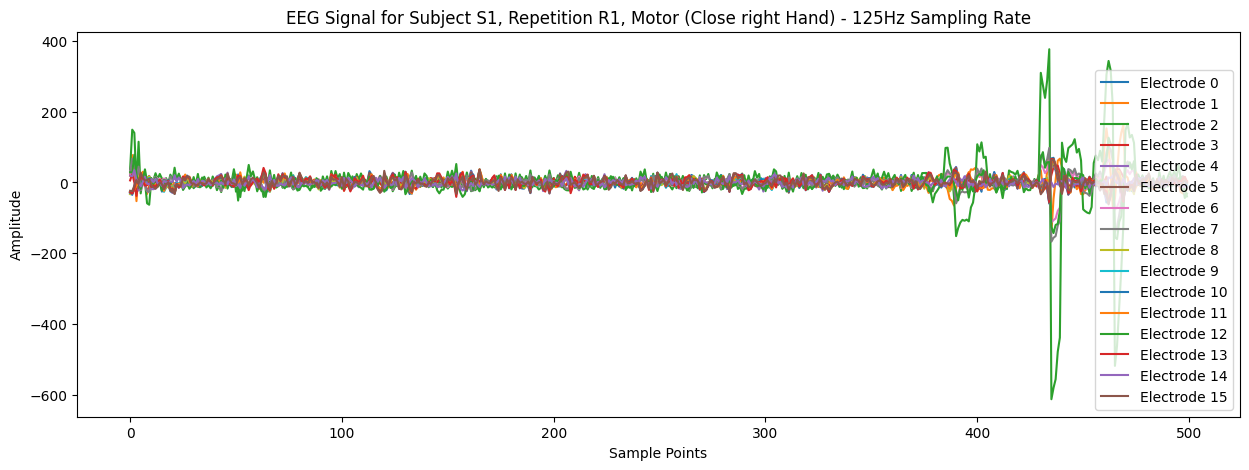

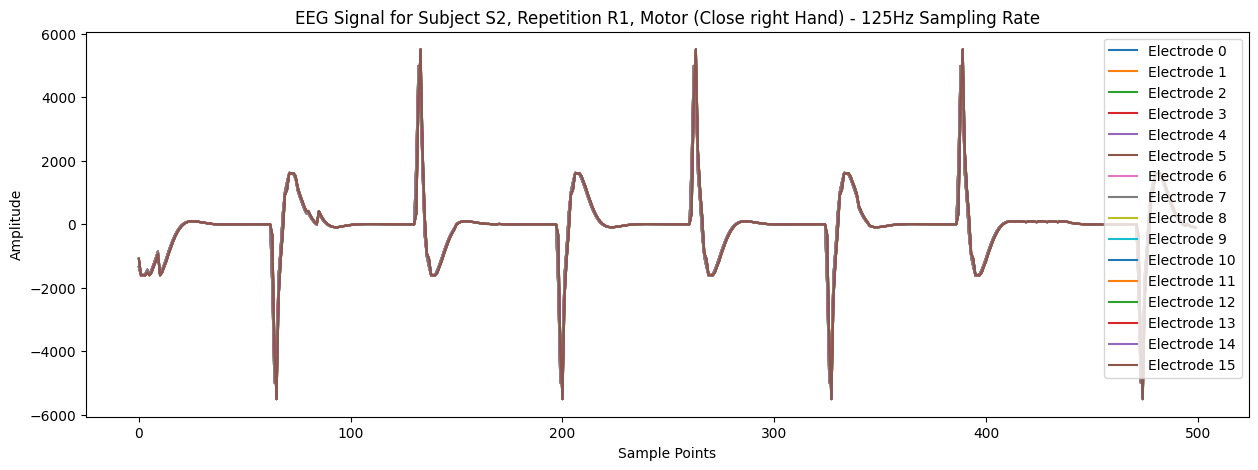

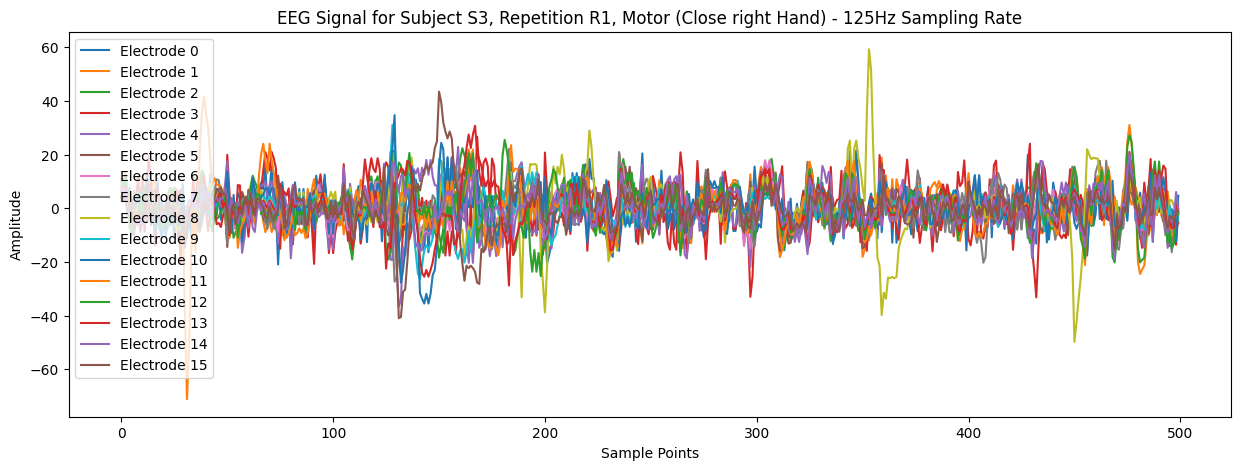

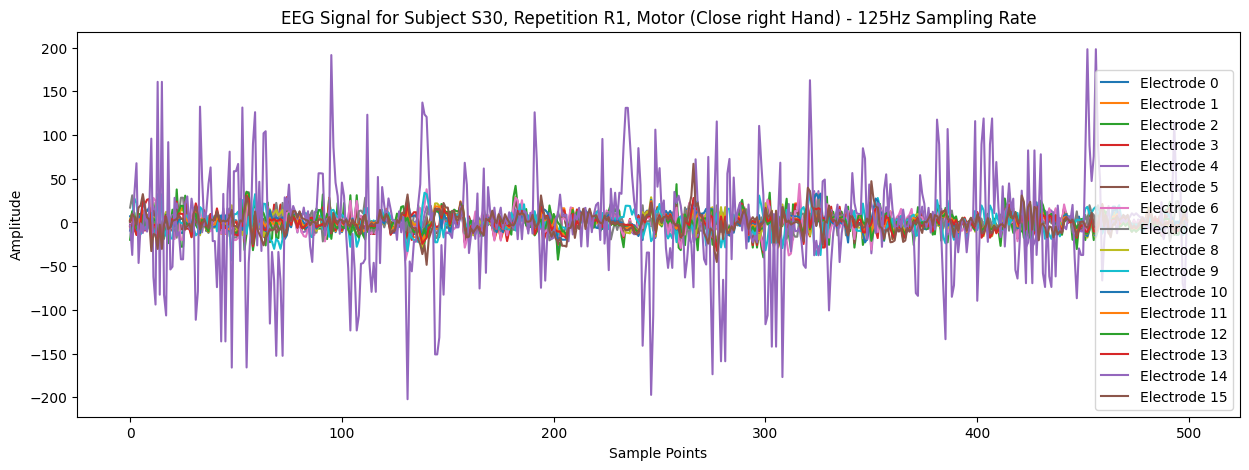

In [71]:
plot_eeg_signal(SubjectID="S1", filename = "S1R1M3_1", label = "Close right Hand")
plot_eeg_signal(SubjectID="S2", filename = "S2R1M3_1", label = "Close right Hand")
plot_eeg_signal(SubjectID="S3", filename = "S3R1M3_1", label = "Close right Hand")
plot_eeg_signal(SubjectID="S30", filename = "S30R1M3_1", label = "Close right Hand")

#### Study 2: Post Normalization of the EEG Signals

In [95]:
eda_df = pd.read_csv(f"./data/S1/S1R1M7_1.csv")
eda_df= eda_df.iloc[:, 1:].apply(lambda x: (x-x.max())/(x.max()-x.min()), axis = 0)
eda_df.apply(lambda x : np.sqrt(np.mean(np.square(x))), axis = 0).values.tolist()

[0.5448227544878689,
 0.6087648761032093,
 0.5264954094500651,
 0.45589974139158157,
 0.49121088149860137,
 0.5468730002069969,
 0.48787474575452666,
 0.5280263091037318,
 0.5065084203337639,
 0.47076267902090824,
 0.4785188066152096,
 0.46728422780018947,
 0.5956011423084543,
 0.4836889330576675,
 0.5583776750004569,
 0.4993749820439203]

In [96]:
def plot_normalization_eeg_signal(SubjectID: str, filename: str, label:str):
    eda_df = pd.read_csv(f"./data/{SubjectID}/{filename}.csv")
    eda_df= eda_df.iloc[:, 1:].apply(lambda x: (x-x.max())/(x.max()-x.min()), axis = 0)
    plt.figure(figsize=(15, 5))
    for i in range(0, 16):
        plt.plot(eda_df.iloc[:, i], label = f"Electrode {i}")
        plt.title(f"EEG Signal for Subject {SubjectID}, Repetition R1, Motor ({label}) - 125Hz Sampling Rate")
        plt.xlabel("Sample Points")
        plt.ylabel("Amplitude")
        plt.legend()

    plt.show()


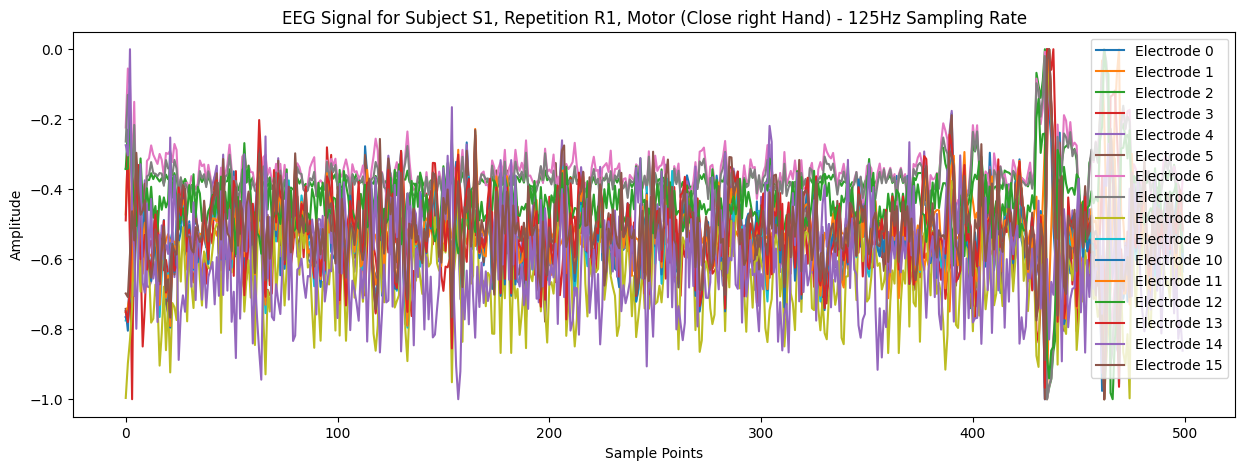

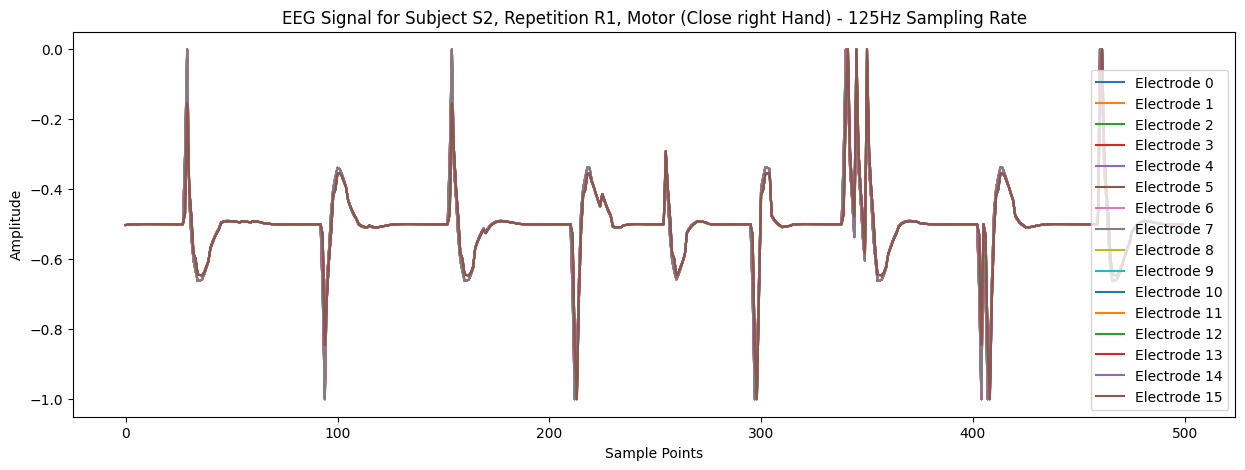

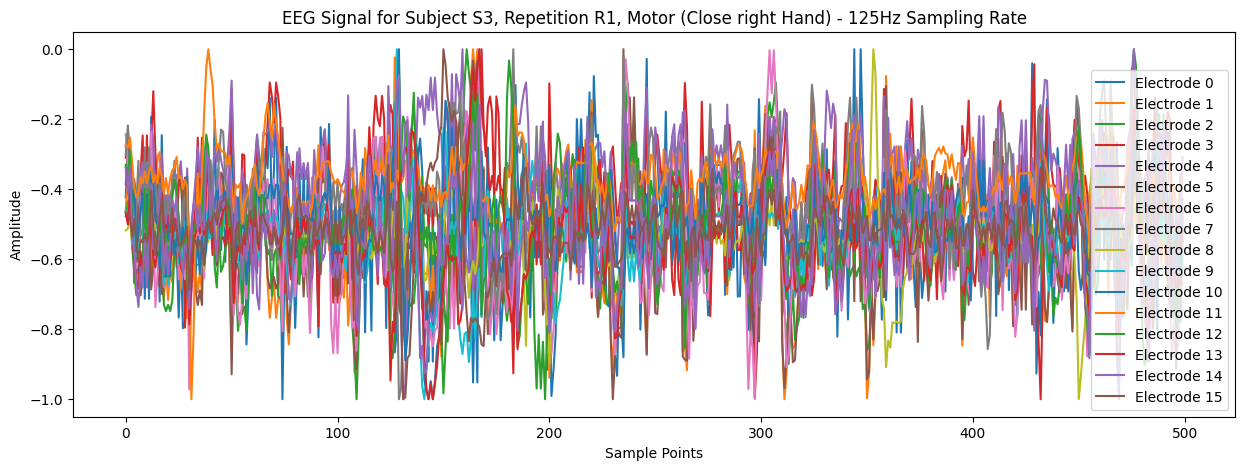

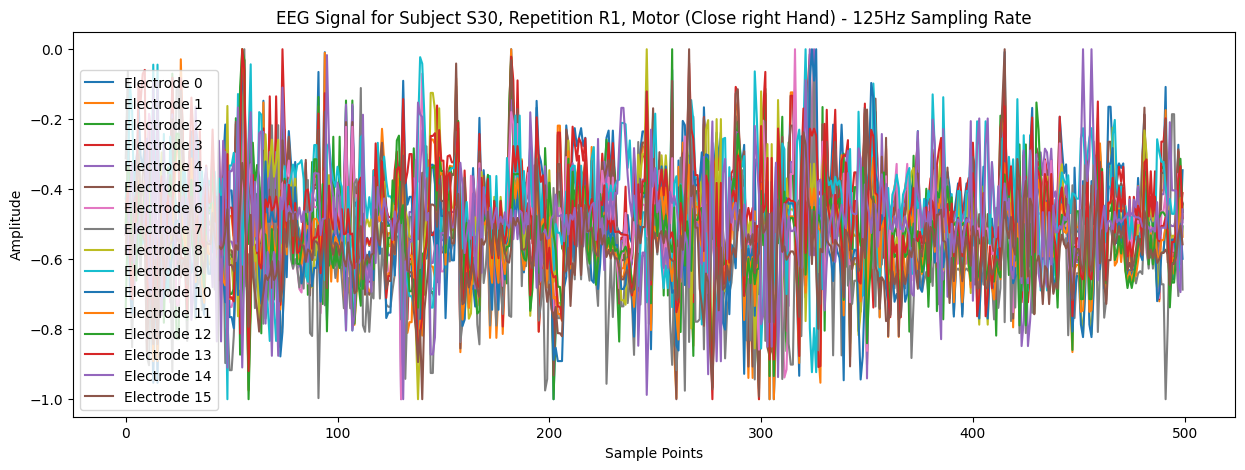

In [97]:
plot_normalization_eeg_signal(SubjectID="S1", filename = "S1R1M3_1", label = "Close right Hand")
plot_normalization_eeg_signal(SubjectID="S2", filename = "S2R1M3_3", label = "Close right Hand")
plot_normalization_eeg_signal(SubjectID="S3", filename = "S3R1M3_1", label = "Close right Hand")
plot_normalization_eeg_signal(SubjectID="S30", filename = "S30R1M3_1", label = "Close right Hand")

# Load Train Files and Preprocess the Data 

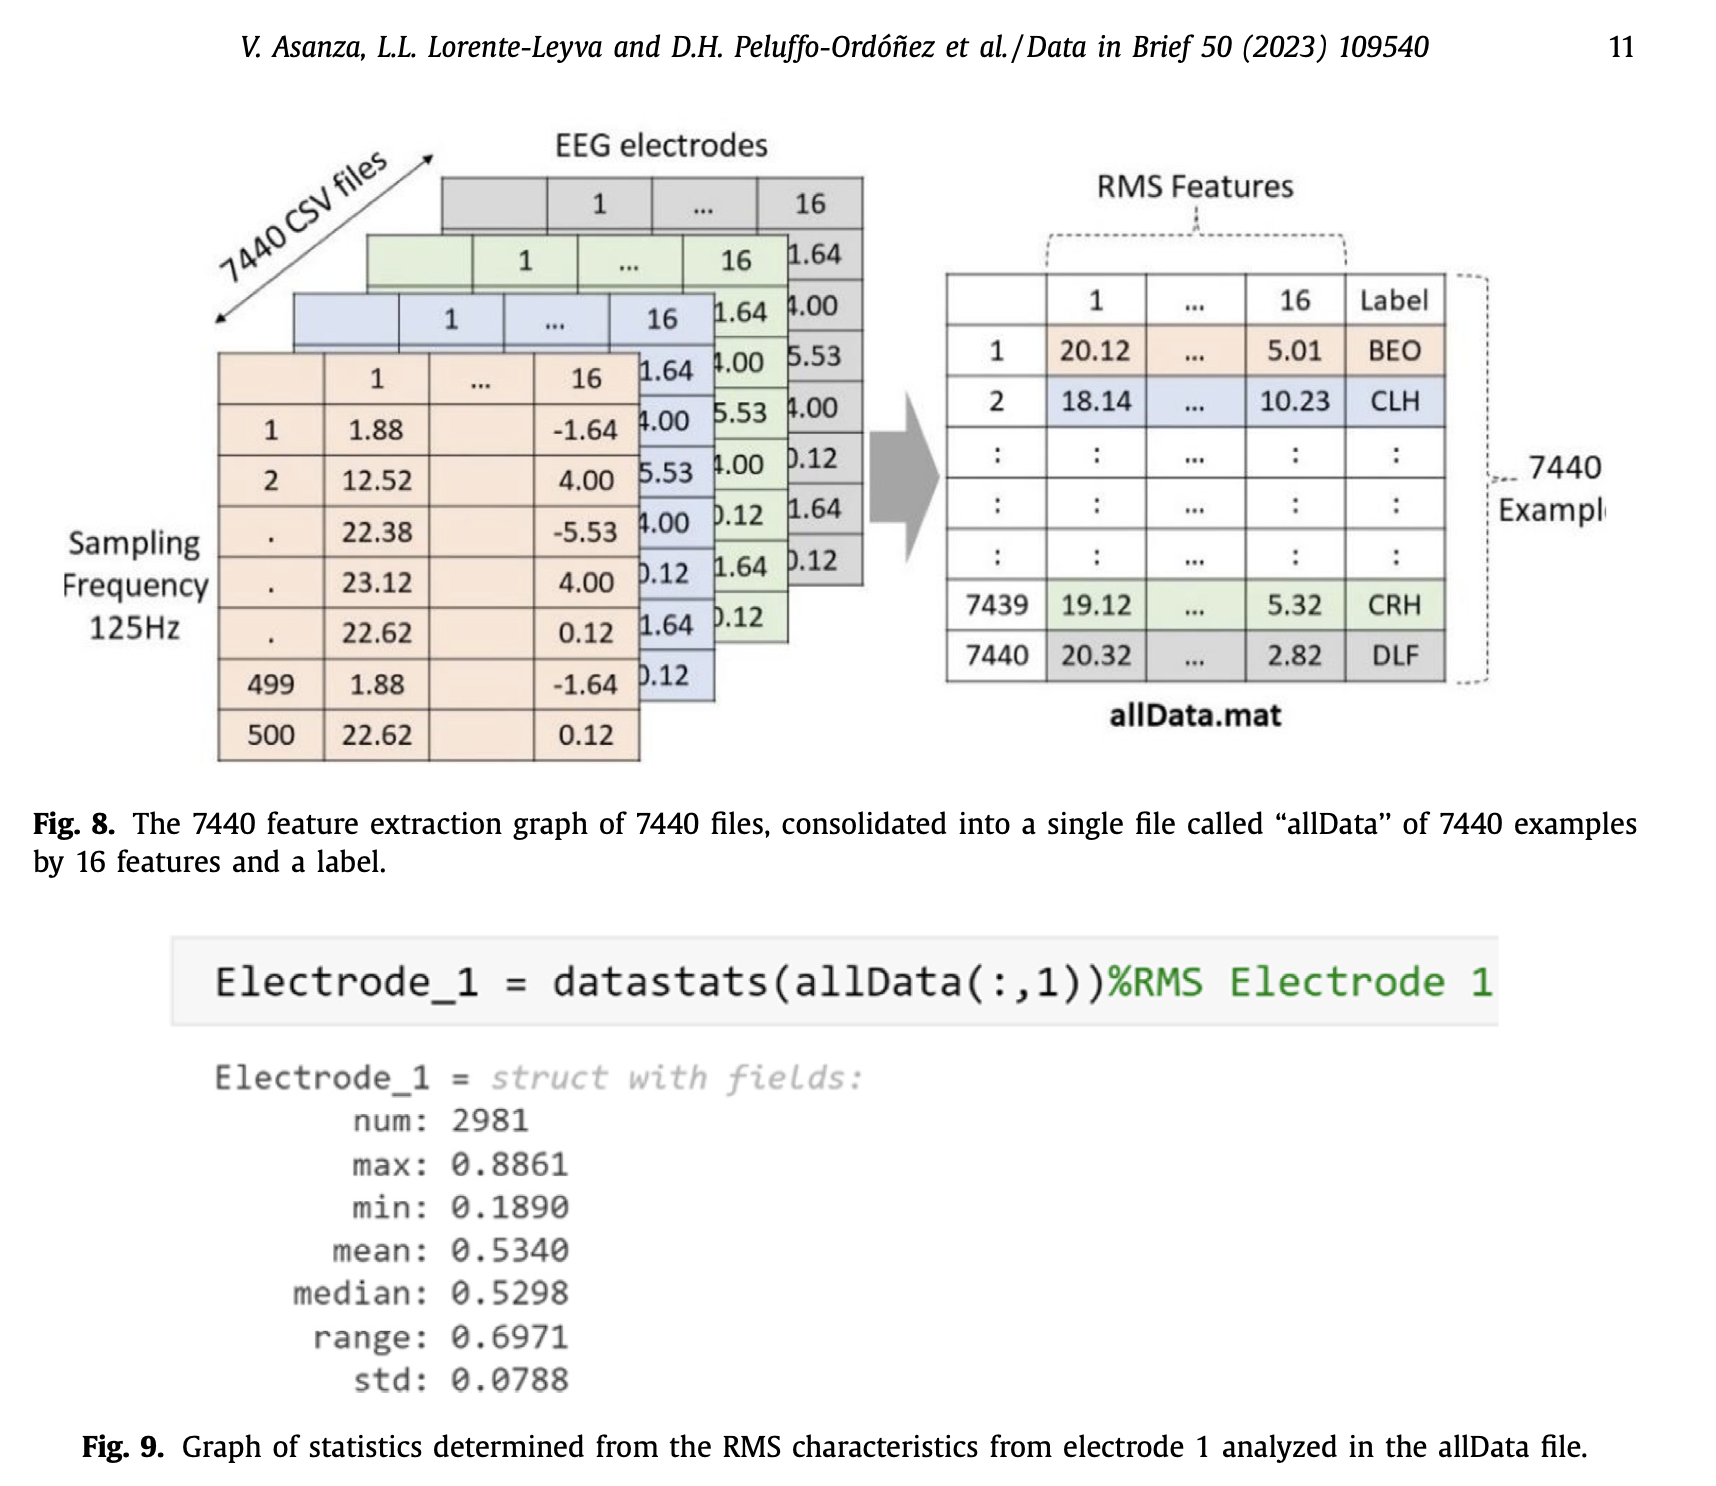

In [130]:
def load_train_files(df:pd.DataFrame):

    # Get the unique filenames from the respective grouped dataframe
    lst_unique_filenames = df["FileName"].unique()
    s1_part = df["SubjectID"].unique()[0]
    m1_part = df["Motor_label"].unique()[0]

    master_rms_features = []

    def load_file(filename:str, s1_part:str, m1_part:str):
        """
            Function: Load the file and return the data as vector of RMS features
            args:
                filename: Name of the file to be loaded
                s1_part: Subject ID part of the filename
        """
        df = pd.read_csv(f"./data/{s1_part}/{filename}")
        
        # Standardize the data
        df = df.iloc[:, 1:].apply(lambda x: (x-x.max())/(x.max()-x.min()), axis = 0)

        # Calculate the RMS features
        rms_features = df.apply(lambda x : np.sqrt(np.mean(np.square(x))), axis = 0).values.tolist()

        rms_label = m1_part[-1]
        master_rms_features.append({
            'SubjectID': s1_part,
            "RepetionNo": filename.split(".")[0][-1],
            'Motor_label': m1_part,
            'Label': int(rms_label),
            **{f'RMS_Feature_{i+1}': val for i, val in enumerate(rms_features)}
        })

    [load_file(filename = unique_file, s1_part=s1_part, m1_part=m1_part) for unique_file in lst_unique_filenames] # Run the function

    return master_rms_features

In [131]:
# Apply to each group and flatten results
grouped_results = train_metadata_information.groupby(["SubjectID", "RepetitionNo", "Motor_label"]).apply(load_train_files)

# Flatten nested list of dicts
flattened = [entry for sublist in grouped_results for entry in sublist]

# Create final DataFrame
final_df = pd.DataFrame(flattened)

In [140]:
final_df = final_df.groupby(["SubjectID", "Motor_label","Label"]).agg({"RMS_Feature_1": np.mean,
                                                            "RMS_Feature_2": np.mean,
                                                            "RMS_Feature_3": np.mean,
                                                            "RMS_Feature_4": np.mean,
                                                            "RMS_Feature_5": np.mean,
                                                            "RMS_Feature_6": np.mean,
                                                            "RMS_Feature_7": np.mean,
                                                            "RMS_Feature_8": np.mean,
                                                            "RMS_Feature_9": np.mean,
                                                            "RMS_Feature_10": np.mean,
                                                            "RMS_Feature_11": np.mean,
                                                            "RMS_Feature_12": np.mean,
                                                            "RMS_Feature_13": np.mean,
                                                            "RMS_Feature_14": np.mean,
                                                            "RMS_Feature_15":np.mean}).reset_index()

In [144]:
final_df.to_csv("./processed_data/RMS_X_train_features.csv")

# Test Dataset

In [145]:
# Apply to each group and flatten results
grouped_results = test_metadata_information.groupby(["SubjectID", "RepetitionNo", "Motor_label"]).apply(load_train_files)

# Flatten nested list of dicts
flattened = [entry for sublist in grouped_results for entry in sublist]

# Create final DataFrame
final_test_df = pd.DataFrame(flattened)

In [146]:
final_test_df = final_test_df.groupby(["SubjectID", "Motor_label","Label"]).agg({"RMS_Feature_1": np.mean,
                                                            "RMS_Feature_2": np.mean,
                                                            "RMS_Feature_3": np.mean,
                                                            "RMS_Feature_4": np.mean,
                                                            "RMS_Feature_5": np.mean,
                                                            "RMS_Feature_6": np.mean,
                                                            "RMS_Feature_7": np.mean,
                                                            "RMS_Feature_8": np.mean,
                                                            "RMS_Feature_9": np.mean,
                                                            "RMS_Feature_10": np.mean,
                                                            "RMS_Feature_11": np.mean,
                                                            "RMS_Feature_12": np.mean,
                                                            "RMS_Feature_13": np.mean,
                                                            "RMS_Feature_14": np.mean,
                                                            "RMS_Feature_15":np.mean}).reset_index()

In [147]:
final_test_df.to_csv("./processed_data/RMS_X_test_features.csv")